<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/03_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - connect my Drive and install rasterio (Colab doesn't have it by default)
from google.colab import drive
drive.mount('/content/drive')
!pip install -q rasterio

Mounted at /content/drive


In [2]:
# Cell 2 - read the 6 feature values under each training point
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

base = "/content/drive/MyDrive/landslide_project"
band_names = ["elevation", "slope", "aspect", "ndvi", "landcover", "dist_river"]

points = gpd.read_file(f"{base}/training_points.geojson")

with rasterio.open(f"{base}/rudraprayag_features.tif") as src:
    # making sure the points are in the same projection as the raster before sampling
    points = points.to_crs(src.crs)
    coords = [(p.x, p.y) for p in points.geometry]
    values = np.array(list(src.sample(coords)))

df = pd.DataFrame(values, columns=band_names)
df["label"] = points["label"].values
df["x"] = [p.x for p in points.geometry]
df["y"] = [p.y for p in points.geometry]

print("points:", len(df))
print(df["label"].value_counts())
print("points with elevation 0 (outside district, shouldn't happen):", (df["elevation"] == 0).sum())
print()
print("average feature values by label (1 = landslide, 0 = no landslide):")
print(df.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))
print()
print("land cover classes by label:")
print(pd.crosstab(df["landcover"], df["label"]))

points: 76
label
1    38
0    38
Name: count, dtype: int64
points with elevation 0 (outside district, shouldn't happen): 0

average feature values by label (1 = landslide, 0 = no landslide):
         elevation  slope  ndvi   dist_river
label                                       
0      2044.290039  33.41  0.62  1079.760010
1      2506.419922  37.23  0.16   316.730011

land cover classes by label:
label       0   1
landcover        
10.0       27   7
30.0       10   9
50.0        1   0
60.0        0  21
100.0       0   1


terrain features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'dist_river']
full features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'dist_river', 'ndvi', 'lc_bare', 'lc_grass', 'lc_other', 'lc_tree']

points per block and label:
label   0   1
block        
0       5  15
1      11   2
2      11   6
3       8   1
4       3  14


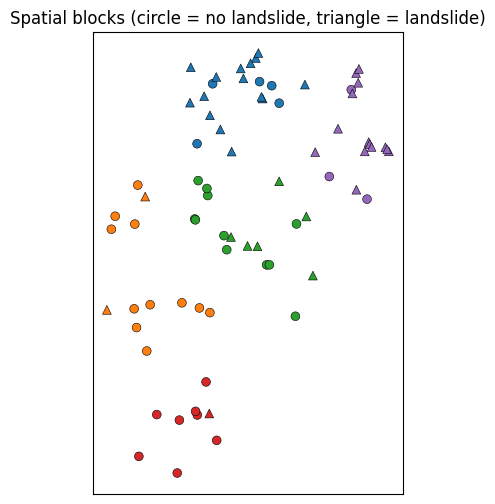

In [3]:
# Cell 3 - prepare features and split the district into spatial blocks
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# aspect is circular (359° and 1° are both north), so I'm turning it into sin/cos
df["aspect_sin"] = np.sin(np.deg2rad(df["aspect"]))
df["aspect_cos"] = np.cos(np.deg2rad(df["aspect"]))

# land cover is categorical, so I'm grouping it into a few classes and one-hot encoding it
# (only for the comparison model - bare land cover mostly IS the landslide scar)
lc_group = df["landcover"].map({10: "tree", 30: "grass", 60: "bare"}).fillna("other")
df = pd.concat([df, pd.get_dummies(lc_group, prefix="lc").astype(int)], axis=1)

terrain_features = ["elevation", "slope", "aspect_sin", "aspect_cos", "dist_river"]
full_features = terrain_features + ["ndvi"] + [c for c in df.columns if c.startswith("lc_")]

# spatial blocks: k-means on the point coordinates gives 5 geographic groups
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["block"] = kmeans.fit_predict(df[["x", "y"]])

print("terrain features:", terrain_features)
print("full features:", full_features)
print()
print("points per block and label:")
print(pd.crosstab(df["block"], df["label"]))

# quick map so I can see the blocks
fig, ax = plt.subplots(figsize=(5, 6))
for lab, marker in [(0, "o"), (1, "^")]:
    sub = df[df["label"] == lab]
    ax.scatter(sub["x"], sub["y"], c=sub["block"], cmap="tab10", vmin=0, vmax=9,
               marker=marker, s=40, edgecolor="k", linewidth=0.4)
ax.set_title("Spatial blocks (circle = no landslide, triangle = landslide)")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [4]:
# Cell 4 - random forest with random CV vs spatial CV, three feature sets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

labels = df["label"].values
feature_sets = {
    "terrain": terrain_features,
    "full (circular)": full_features,
    "coordinates only": ["x", "y"],
}

def make_rf(seed):
    # small dataset, so I'm keeping leaves from getting too tiny (min 2 points)
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  random_state=seed, n_jobs=-1)

def random_cv_auc(features, seed):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    prob = cross_val_predict(make_rf(seed), df[features], labels, cv=cv,
                             method="predict_proba")[:, 1]
    return roc_auc_score(labels, prob)

def spatial_cv_auc(features, seed):
    # new block layout each repeat, then hold out one block at a time
    blocks = KMeans(n_clusters=5, random_state=seed, n_init=10).fit_predict(df[["x", "y"]])
    prob = cross_val_predict(make_rf(seed), df[features], labels, groups=blocks,
                             cv=LeaveOneGroupOut(), method="predict_proba")[:, 1]
    # pooling predictions from all held-out blocks, since some blocks have only one label
    return roc_auc_score(labels, prob)

rows = []
for name, feats in feature_sets.items():
    for seed in range(10):
        rows.append({"model": name, "cv": "random", "seed": seed, "auc": random_cv_auc(feats, seed)})
        rows.append({"model": name, "cv": "spatial", "seed": seed, "auc": spatial_cv_auc(feats, seed)})

results = pd.DataFrame(rows)
summary = results.groupby(["model", "cv"])["auc"].agg(["mean", "std"]).round(3)
print(summary)

                           mean    std
model            cv                   
coordinates only random   0.791  0.022
                 spatial  0.829  0.007
full (circular)  random   0.946  0.005
                 spatial  0.947  0.004
terrain          random   0.841  0.017
                 spatial  0.852  0.004


In [5]:
# Cell 5 - which terrain feature carries the signal? (spatial CV, 10 repeats each)
feature_groups = {
    "elevation": ["elevation"],
    "slope": ["slope"],
    "aspect": ["aspect_sin", "aspect_cos"],   # sin and cos belong together
    "dist_river": ["dist_river"],
}

rows = []
for name, feats in feature_groups.items():
    rest = [f for f in terrain_features if f not in feats]
    for seed in range(10):
        rows.append({"test": f"only {name}", "auc": spatial_cv_auc(feats, seed)})
        rows.append({"test": f"without {name}", "auc": spatial_cv_auc(rest, seed)})

diag = pd.DataFrame(rows).groupby("test")["auc"].agg(["mean", "std"]).round(3)
print(diag)
print()
print("reference - all terrain features:", summary.loc[("terrain", "spatial"), "mean"])
print("reference - coordinates only:   ", summary.loc[("coordinates only", "spatial"), "mean"])
print()
# how much is each feature just "where you are"? (y = northing, x = easting)
for f in ["elevation", "slope", "dist_river"]:
    print(f"correlation of {f} with northing: {np.corrcoef(df[f], df['y'])[0, 1]:.2f}")

                     mean    std
test                            
only aspect         0.458  0.006
only dist_river     0.792  0.005
only elevation      0.497  0.006
only slope          0.368  0.005
without aspect      0.896  0.005
without dist_river  0.591  0.012
without elevation   0.784  0.006
without slope       0.833  0.004

reference - all terrain features: 0.852
reference - coordinates only:    0.829

correlation of elevation with northing: 0.71
correlation of slope with northing: 0.12
correlation of dist_river with northing: -0.48


search radius used per landslide: {3000: 38}
label
1    38
0    38
Name: count, dtype: int64

averages by label (matched set):
         elevation      slope  ndvi  dist_river
label                                          
0      2648.919922  34.610001  0.59  686.780029
1      2506.419922  37.230000  0.16  316.730011


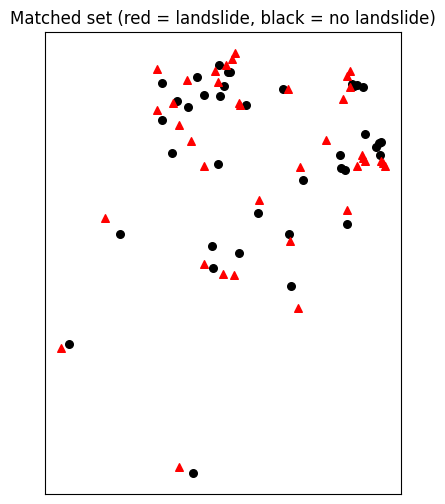

In [6]:
# Cell 6 - new no-landslide points drawn NEAR the landslides (same valleys),
# so the model can't win just by knowing north from south
tif = f"{base}/rudraprayag_features.tif"
rng = np.random.default_rng(42)

with rasterio.open(tif) as src:
    elev_full = src.read(1)
    lc_full = src.read(5)
    tr = src.transform

# same allowed terrain as before: inside district, below 3500 m, not snow/ice or water
valid = (elev_full > 0) & (elev_full < 3500) & (lc_full != 70) & (lc_full != 80)
vr, vc = np.where(valid)
take = rng.choice(len(vr), size=min(200_000, len(vr)), replace=False)
px, py = rasterio.transform.xy(tr, vr[take], vc[take])
px, py = np.array(px), np.array(py)

ls_xy = df.loc[df["label"] == 1, ["x", "y"]].values

# every candidate must stay more than 500 m from ANY landslide (same rule as before)
d_any = np.full(len(px), np.inf)
for lx, ly in ls_xy:
    d_any = np.minimum(d_any, np.hypot(px - lx, py - ly))
ok = d_any > 500

# for each landslide, pick one stable point within 3 km (widen to 5 or 10 km if nothing fits)
used = np.zeros(len(px), dtype=bool)
chosen, radius_used = [], []
for lx, ly in ls_xy:
    d = np.hypot(px - lx, py - ly)
    for radius in [3000, 5000, 10000]:
        cand = np.where(ok & ~used & (d <= radius))[0]
        if len(cand) > 0:
            break
    j = rng.choice(cand)
    used[j] = True
    chosen.append(j)
    radius_used.append(radius)

print("search radius used per landslide:", pd.Series(radius_used).value_counts().to_dict())

# read the 6 features at the new stable points
new_xy = list(zip(px[chosen], py[chosen]))
with rasterio.open(tif) as src:
    new_vals = np.array(list(src.sample(new_xy)))

stable_m = pd.DataFrame(new_vals, columns=band_names)
stable_m["label"] = 0
stable_m["x"] = px[chosen]
stable_m["y"] = py[chosen]

df_m = pd.concat([df.loc[df["label"] == 1, band_names + ["label", "x", "y"]], stable_m],
                 ignore_index=True)
df_m["aspect_sin"] = np.sin(np.deg2rad(df_m["aspect"]))
df_m["aspect_cos"] = np.cos(np.deg2rad(df_m["aspect"]))

# saving the matched set separately - the original training_points.geojson stays untouched
gpd.GeoDataFrame(df_m[["label"]], geometry=gpd.points_from_xy(df_m["x"], df_m["y"]),
                 crs="EPSG:32644").to_file(f"{base}/training_points_matched.geojson", driver="GeoJSON")

print(df_m["label"].value_counts())
print()
print("averages by label (matched set):")
print(df_m.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))

fig, ax = plt.subplots(figsize=(5, 6))
for lab, marker, colour in [(0, "o", "black"), (1, "^", "red")]:
    sub = df_m[df_m["label"] == lab]
    ax.scatter(sub["x"], sub["y"], marker=marker, c=colour, s=30)
ax.set_title("Matched set (red = landslide, black = no landslide)")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [7]:
# Cell 7 - same three models, now on the matched points
# land cover columns for the comparison model (same grouping as before)
lc_m = df_m["landcover"].map({10: "tree", 30: "grass", 60: "bare"}).fillna("other")
lc_cols = [c for c in full_features if c.startswith("lc_")]
df_m = pd.concat([df_m, pd.get_dummies(lc_m, prefix="lc").astype(int)
                  .reindex(columns=lc_cols, fill_value=0)], axis=1)

def evaluate(data, features, seed, mode):
    lab = data["label"].values
    if mode == "random":
        groups = None
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    else:
        groups = KMeans(n_clusters=5, random_state=seed, n_init=10).fit_predict(data[["x", "y"]])
        cv = LeaveOneGroupOut()
    prob = cross_val_predict(make_rf(seed), data[features], lab, cv=cv, groups=groups,
                             method="predict_proba")[:, 1]
    pooled = roc_auc_score(lab, prob)
    within = np.nan
    if mode == "spatial":
        # AUC inside each held-out block - only blocks that contain both labels count
        per_block = [roc_auc_score(lab[groups == g], prob[groups == g])
                     for g in np.unique(groups) if len(np.unique(lab[groups == g])) == 2]
        within = np.mean(per_block)
    return pooled, within

rows = []
for name, feats in feature_sets.items():
    for seed in range(10):
        for mode in ["random", "spatial"]:
            pooled, within = evaluate(df_m, feats, seed, mode)
            rows.append({"model": name, "cv": mode, "seed": seed,
                         "pooled_auc": pooled, "within_block_auc": within})

results_m = pd.DataFrame(rows)
summary_m = results_m.groupby(["model", "cv"])[["pooled_auc", "within_block_auc"]].agg(["mean", "std"]).round(3)
print(summary_m)

                         pooled_auc        within_block_auc       
                               mean    std             mean    std
model            cv                                               
coordinates only random       0.400  0.040              NaN    NaN
                 spatial      0.485  0.028            0.386  0.026
full (circular)  random       0.942  0.007              NaN    NaN
                 spatial      0.928  0.005            0.935  0.004
terrain          random       0.669  0.033              NaN    NaN
                 spatial      0.623  0.023            0.721  0.048


In [8]:
# Cell 8 - which terrain features matter once location is removed? (within-block AUC)
print("search radius used per landslide:", pd.Series(radius_used).value_counts().to_dict())
print()
print("averages by label (matched set):")
print(df_m.groupby("label")[["elevation", "slope", "ndvi", "dist_river"]].mean().round(2))
print()

rows = []
for name, feats in feature_groups.items():
    rest = [f for f in terrain_features if f not in feats]
    for seed in range(10):
        _, only_auc = evaluate(df_m, feats, seed, "spatial")
        _, without_auc = evaluate(df_m, rest, seed, "spatial")
        rows.append({"test": f"only {name}", "auc": only_auc})
        rows.append({"test": f"without {name}", "auc": without_auc})

diag_m = pd.DataFrame(rows).groupby("test")["auc"].agg(["mean", "std"]).round(3)
print(diag_m)
print()
print("reference - all terrain features (within-block):",
      summary_m.loc[("terrain", "spatial"), ("within_block_auc", "mean")])

search radius used per landslide: {3000: 38}

averages by label (matched set):
         elevation      slope  ndvi  dist_river
label                                          
0      2648.919922  34.610001  0.59  686.780029
1      2506.419922  37.230000  0.16  316.730011

                     mean    std
test                            
only aspect         0.422  0.006
only dist_river     0.669  0.041
only elevation      0.563  0.021
only slope          0.660  0.065
without aspect      0.737  0.050
without dist_river  0.716  0.016
without elevation   0.520  0.104
without slope       0.704  0.044

reference - all terrain features (within-block): 0.721


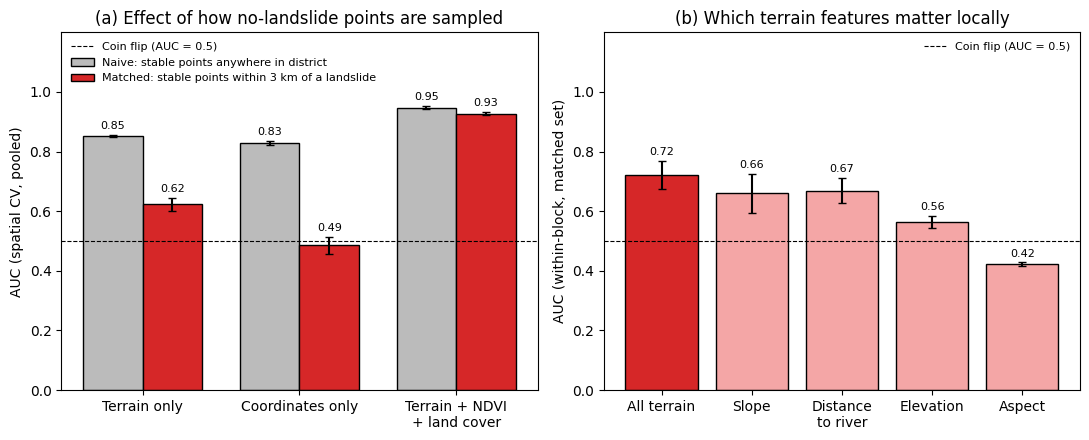

In [9]:
# Cell 9 - Figure 4: model evaluation (naive vs matched sampling + which features matter)
models = ["terrain", "coordinates only", "full (circular)"]
model_labels = ["Terrain only", "Coordinates only", "Terrain + NDVI\n+ land cover"]

# panel (a): pooled spatial-CV AUC for both sampling designs, so the metric is the same
naive = results[results["cv"] == "spatial"].groupby("model")["auc"].agg(["mean", "std"]).loc[models]
matched = results_m[results_m["cv"] == "spatial"].groupby("model")["pooled_auc"].agg(["mean", "std"]).loc[models]

# panel (b): within-block AUC on the matched set, all terrain + each feature alone
b_tests = ["only slope", "only dist_river", "only elevation", "only aspect"]
b_means = [summary_m.loc[("terrain", "spatial"), ("within_block_auc", "mean")]] + [diag_m.loc[t, "mean"] for t in b_tests]
b_stds = [summary_m.loc[("terrain", "spatial"), ("within_block_auc", "std")]] + [diag_m.loc[t, "std"] for t in b_tests]
b_labels = ["All terrain", "Slope", "Distance\nto river", "Elevation", "Aspect"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.arange(len(models))
w = 0.38
ax1.bar(x - w/2, naive["mean"], w, yerr=naive["std"], capsize=3, color="#bbbbbb",
        edgecolor="black", label="Naive: stable points anywhere in district")
ax1.bar(x + w/2, matched["mean"], w, yerr=matched["std"], capsize=3, color="#d62728",
        edgecolor="black", label="Matched: stable points within 3 km of a landslide")
# labels go above the error bar, not just above the bar (0.49 was sitting on its error bar)
for xi, m, s in zip(x - w/2, naive["mean"], naive["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
for xi, m, s in zip(x + w/2, matched["mean"], matched["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
ax1.axhline(0.5, ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.2)
ax1.set_ylabel("AUC (spatial CV, pooled)")
ax1.set_title("(a) Effect of how no-landslide points are sampled")
ax1.legend(loc="upper left", fontsize=8, frameon=False)

# the first bar (all terrain) is the headline, so I'm making it stand out
colours = ["#d62728"] + ["#f4a6a6"] * 4
ax2.bar(np.arange(5), b_means, yerr=b_stds, capsize=3, color=colours, edgecolor="black")
for i, (m, s) in enumerate(zip(b_means, b_stds)):
    ax2.text(i, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
ax2.axhline(0.5, ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")
ax2.legend(loc="upper right", fontsize=8, frameon=False)
ax2.set_xticks(np.arange(5))
ax2.set_xticklabels(b_labels)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel("AUC (within-block, matched set)")
ax2.set_title("(b) Which terrain features matter locally")
# AUC can't go above 1, so I only want ticks up to 1.0 (the extra space is for labels)
for ax in (ax1, ax2):
    ax.set_yticks(np.arange(0, 1.01, 0.2))
plt.tight_layout()
plt.savefig(f"{base}/figures/fig4_model_evaluation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig4_model_evaluation.pdf", bbox_inches="tight")
plt.show()

In [10]:
# Cell 10 - lat/lon copy of the matched points for GitHub (the Drive copy stays in UTM)
m = gpd.read_file(f"{base}/training_points_matched.geojson")
m.to_crs("EPSG:4326").to_file(f"{base}/training_points_matched_wgs84.geojson", driver="GeoJSON")
print(len(m), "points saved")

76 points saved


pixels to score: 1767254
count    1767254.000
mean           0.380
std            0.199
min            0.033
25%            0.215
50%            0.348
75%            0.525
max            0.968
dtype: float64


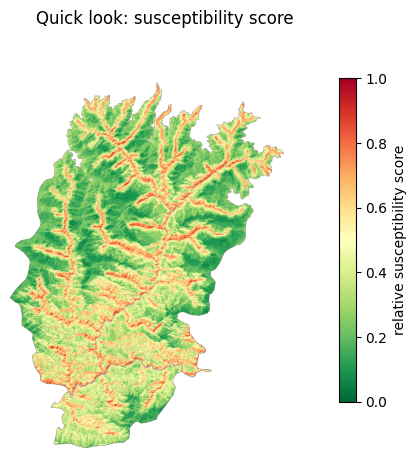

In [13]:
# Cell 11 - train the final model on all matched points, then score every pixel in the district
final_rf = make_rf(42).fit(df_m[terrain_features], df_m["label"])

with rasterio.open(tif) as src:
    bands = src.read().astype("float32")
    profile = src.profile

elev_b, slope_b, aspect_b, ndvi_b, lc_b, dist_b = bands

# same terrain the training points came from; everything else = "not modelled"
domain = (elev_b > 0) & (elev_b < 3500) & (lc_b != 70) & (lc_b != 80)

X = pd.DataFrame({
    "elevation": elev_b[domain],
    "slope": slope_b[domain],
    "aspect_sin": np.sin(np.deg2rad(aspect_b[domain])),
    "aspect_cos": np.cos(np.deg2rad(aspect_b[domain])),
    "dist_river": dist_b[domain],
})[terrain_features]   # same column order as in training
print("pixels to score:", len(X))

score = final_rf.predict_proba(X)[:, 1]

# put the scores back into a map-shaped array; NaN = not modelled
susc = np.full(elev_b.shape, np.nan, dtype="float32")
susc[domain] = score

profile.update(count=1, dtype="float32", nodata=np.nan)
# single-draw map gets its own name, so it can never overwrite the averaged map again
with rasterio.open(f"{base}/rudraprayag_susceptibility_single_draw.tif", "w", **profile) as dst:
    dst.write(susc, 1)

print(pd.Series(score).describe().round(3))

# quick look - the proper Figure 5 comes next
plt.figure(figsize=(5, 6))
plt.imshow(susc, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(label="relative susceptibility score", shrink=0.7)
plt.title("Quick look: susceptibility score")
plt.axis("off")
plt.show()

class breaks (score): [0.193 0.285 0.383 0.538]
modelled area more than 5 km from any training point: 38.3%
landslides outside modelled area: 0
Very low      0
Low           0
Moderate      0
High          0
Very high    38
Name: count, dtype: int64


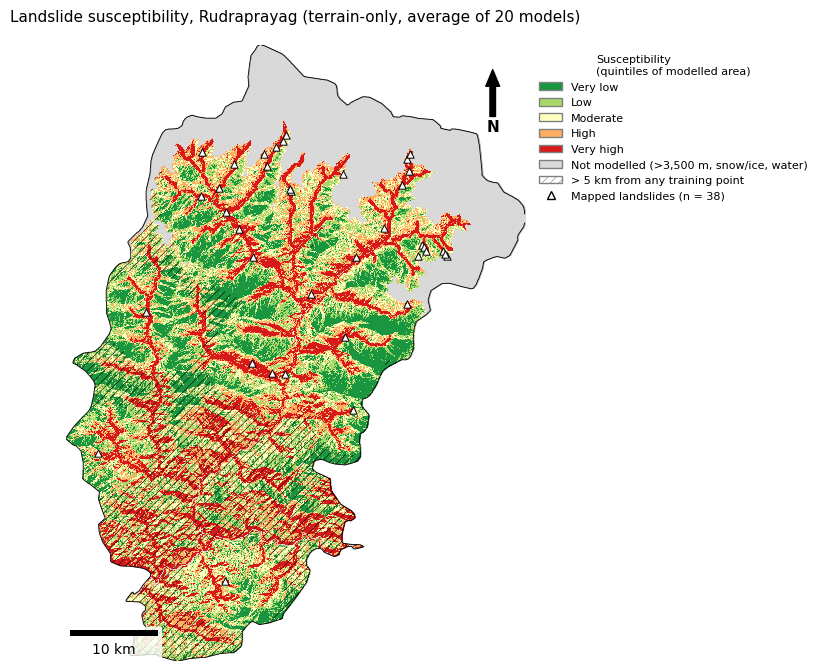

In [18]:
# Cell 12 - Figure 5: susceptibility classes, extrapolation zone, landslides on top
!pip install -q matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from rasterio.plot import plotting_extent

with rasterio.open(f"{base}/rudraprayag_susceptibility.tif") as src:
    susc = src.read(1)
    ext = plotting_extent(src)
    tr_s = src.transform

# quintiles: each class = 20% of the modelled area
modelled = ~np.isnan(susc)
breaks = np.quantile(susc[modelled], [0.2, 0.4, 0.6, 0.8])
classes = np.full(susc.shape, np.nan, dtype="float32")
classes[modelled] = np.digitize(susc[modelled], breaks)   # 0 = very low ... 4 = very high
class_names = ["Very low", "Low", "Moderate", "High", "Very high"]
class_colours = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
print("class breaks (score):", np.round(breaks, 3))

# where is the model extrapolating? distance from each modelled pixel to the nearest training point
r_idx, c_idx = np.where(modelled)
mx = tr_s.c + (c_idx + 0.5) * tr_s.a   # pixel centre x (metres)
my = tr_s.f + (r_idx + 0.5) * tr_s.e   # pixel centre y (metres)
d_min = np.full(len(mx), np.inf)
for tx, ty in df_m[["x", "y"]].values:
    d_min = np.minimum(d_min, np.hypot(mx - tx, my - ty))
far = np.zeros(susc.shape, dtype=int)
far[r_idx, c_idx] = (d_min > 5000).astype(int)
print(f"modelled area more than 5 km from any training point: {100 * far[modelled].mean():.1f}%")

# training-data check (NOT validation): which class do my 38 landslides fall in?
ls = df_m[df_m["label"] == 1]
rows_l, cols_l = rasterio.transform.rowcol(tr_s, ls["x"].values, ls["y"].values)
ls_classes = classes[np.array(rows_l), np.array(cols_l)]
print("landslides outside modelled area:", int(np.isnan(ls_classes).sum()))
print(pd.Series(ls_classes[~np.isnan(ls_classes)].astype(int)).map(dict(enumerate(class_names)))
      .value_counts().reindex(class_names, fill_value=0))

# --- the figure ---
plt.rcParams["hatch.linewidth"] = 0.4
fig, ax = plt.subplots(figsize=(9, 8))
district = elev_b > 0
ax.imshow(np.where(district, 1, np.nan), cmap=ListedColormap(["#d9d9d9"]), extent=ext)
ax.imshow(classes, cmap=ListedColormap(class_colours), vmin=-0.5, vmax=4.5,
          extent=ext, interpolation="nearest")
ax.contourf(far, levels=[0.5, 1.5], colors="none", hatches=["////"], extent=ext, origin="upper")
ax.contour(district.astype(int), levels=[0.5], colors="black", linewidths=0.6,
           extent=ext, origin="upper")
ax.scatter(ls["x"], ls["y"], marker="^", s=28, c="white", edgecolor="black",
           linewidth=0.7, zorder=5)

ax.add_artist(ScaleBar(1, "m", location="lower left", length_fraction=0.25, box_alpha=0.8))
ax.annotate("N", xy=(0.93, 0.96), xytext=(0.93, 0.86), xycoords="axes fraction",
            ha="center", fontsize=11, fontweight="bold",
            arrowprops=dict(facecolor="black", width=4, headwidth=10))

handles = [Patch(facecolor=c, edgecolor="grey", label=n) for n, c in zip(class_names, class_colours)]
handles += [
    Patch(facecolor="#d9d9d9", edgecolor="grey", label="Not modelled (>3,500 m, snow/ice, water)"),
    Patch(facecolor="white", edgecolor="grey", hatch="////", label="> 5 km from any training point"),
    Line2D([], [], marker="^", ls="", markerfacecolor="white", markeredgecolor="black",
           label=f"Mapped landslides (n = {len(ls)})"),
]
# the district fills every corner, so the legend goes outside the map on the right
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8,
          frameon=False, title="Susceptibility\n(quintiles of modelled area)", title_fontsize=8)
ax.set_title("Landslide susceptibility, Rudraprayag (terrain-only, average of 20 models)", fontsize=11)
ax.set_axis_off()

plt.savefig(f"{base}/figures/fig5_susceptibility_map.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig5_susceptibility_map.pdf", bbox_inches="tight")
plt.show()

In [14]:
# Cell 13 - held-out check: which class do landslides fall in when the model never saw them?
blocks_c = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(df_m[["x", "y"]])
rows_all, cols_all = rasterio.transform.rowcol(tr_s, df_m["x"].values, df_m["y"].values)
rows_all, cols_all = np.array(rows_all), np.array(cols_all)

held_class = np.full(len(df_m), np.nan)
for g in range(5):
    train = blocks_c != g
    rf_g = make_rf(42).fit(df_m.loc[train, terrain_features], df_m.loc[train, "label"])
    s = rf_g.predict_proba(X)[:, 1]                    # score the whole district with this fold's model
    br = np.quantile(s, [0.2, 0.4, 0.6, 0.8])          # this model's own quintile classes
    grid = np.full(domain.shape, np.nan, dtype="float32")
    grid[domain] = np.digitize(s, br)
    idx = np.where(blocks_c == g)[0]
    held_class[idx] = grid[rows_all[idx], cols_all[idx]]
    print(f"block {g}: trained on {train.sum()} points, checked {len(idx)} held-out points")

res = pd.DataFrame({"label": df_m["label"].values, "cls": held_class})
res["class_name"] = res["cls"].map(dict(enumerate(class_names)))
tab = pd.crosstab(res["class_name"], res["label"]).reindex(class_names, fill_value=0)
tab.columns = ["stable (held out)", "landslide (held out)"]
print()
print(tab)
print()
share_ls = (res.loc[res["label"] == 1, "cls"] >= 3).mean()
share_st = (res.loc[res["label"] == 0, "cls"] >= 3).mean()
print(f"held-out landslides in High/Very high: {100 * share_ls:.0f}%  (chance level: 40%)")
print(f"held-out stable points in High/Very high: {100 * share_st:.0f}%")

block 0: trained on 47 points, checked 29 held-out points
block 1: trained on 47 points, checked 29 held-out points
block 2: trained on 64 points, checked 12 held-out points
block 3: trained on 74 points, checked 2 held-out points
block 4: trained on 72 points, checked 4 held-out points

            stable (held out)  landslide (held out)
class_name                                         
Very low                    2                     0
Low                         5                     2
Moderate                    6                     3
High                       14                    17
Very high                  11                    16

held-out landslides in High/Very high: 87%  (chance level: 40%)
held-out stable points in High/Very high: 66%


In [15]:
# Cell 14 - slope circularity check: re-draw stable points with the SAME slope > 25° rule the landslides had to pass
rng = np.random.default_rng(42)
tif = f"{base}/rudraprayag_features.tif"
with rasterio.open(tif) as src:
    elev_full = src.read(1)
    slope_full = src.read(2)
    lc_full = src.read(5)
    tr = src.transform

# how many of my landslide points themselves are below 25°? (points are patch centres, the filter was per pixel)
print("landslide points with slope <= 25° at their centre:",
      int((df_m.loc[df_m["label"] == 1, "slope"] <= 25).sum()), "of 38")

# same allowed terrain as before, PLUS slope > 25° (the candidate filter)
valid_steep = (elev_full > 0) & (elev_full < 3500) & (lc_full != 70) & (lc_full != 80) & (slope_full > 25)
vr, vc = np.where(valid_steep)
take = rng.choice(len(vr), size=min(200_000, len(vr)), replace=False)
px = tr.c + (vc[take] + 0.5) * tr.a          # pixel centre x (metres)
py = tr.f + (vr[take] + 0.5) * tr.e          # pixel centre y (metres)

ls_xy = df_m.loc[df_m["label"] == 1, ["x", "y"]].values
d_any = np.full(len(px), np.inf)
for lx, ly in ls_xy:
    d_any = np.minimum(d_any, np.hypot(px - lx, py - ly))
ok = d_any > 500

used = np.zeros(len(px), dtype=bool)
chosen, radius_used = [], []
for lx, ly in ls_xy:
    d = np.hypot(px - lx, py - ly)
    for radius in [3000, 5000, 10000]:
        cand = np.where(ok & ~used & (d <= radius))[0]
        if len(cand) > 0:
            break
    j = rng.choice(cand)
    used[j] = True
    chosen.append(j)
    radius_used.append(radius)
print("search radius used per landslide:", pd.Series(radius_used).value_counts().to_dict())

with rasterio.open(tif) as src:
    new_vals = np.array(list(src.sample(list(zip(px[chosen], py[chosen])))))
stable_s = pd.DataFrame(new_vals, columns=band_names)
stable_s["label"] = 0
stable_s["x"], stable_s["y"] = px[chosen], py[chosen]

df_s = pd.concat([df_m.loc[df_m["label"] == 1, band_names + ["label", "x", "y"]], stable_s], ignore_index=True)
df_s["aspect_sin"] = np.sin(np.deg2rad(df_s["aspect"]))
df_s["aspect_cos"] = np.cos(np.deg2rad(df_s["aspect"]))
gpd.GeoDataFrame(df_s[["label"]], geometry=gpd.points_from_xy(df_s["x"], df_s["y"]),
                 crs="EPSG:32644").to_file(f"{base}/training_points_matched_steep.geojson", driver="GeoJSON")

print("\naverages by label (slope-matched set):")
print(df_s.groupby("label")[["elevation", "slope", "dist_river"]].mean().round(1))

# same within-block evaluation as before, on the slope-matched set
tests = {"terrain (all)": terrain_features, "only slope": ["slope"],
         "only dist_river": ["dist_river"], "coordinates only": ["x", "y"]}
rows = []
for name, feats in tests.items():
    for seed in range(10):
        _, w = evaluate(df_s, feats, seed, "spatial")
        rows.append({"test": name, "auc": w})
steep = pd.DataFrame(rows).groupby("test")["auc"].agg(["mean", "std"]).reindex(list(tests))

# side by side with the original matched set
steep["before (original matched)"] = [
    summary_m.loc[("terrain", "spatial"), ("within_block_auc", "mean")],
    diag_m.loc["only slope", "mean"],
    diag_m.loc["only dist_river", "mean"],
    summary_m.loc[("coordinates only", "spatial"), ("within_block_auc", "mean")],
]
print("\nwithin-block AUC, slope-matched set (mean, std) vs original matched set:")
print(steep.round(3))

landslide points with slope <= 25° at their centre: 2 of 38
search radius used per landslide: {3000: 38}

averages by label (slope-matched set):
         elevation      slope  dist_river
label                                    
0      2602.399902  37.500000  609.099976
1      2506.399902  37.200001  316.700012

within-block AUC, slope-matched set (mean, std) vs original matched set:
                   mean    std  before (original matched)
test                                                     
terrain (all)     0.536  0.006                      0.721
only slope        0.637  0.005                      0.660
only dist_river   0.550  0.026                      0.669
coordinates only  0.475  0.036                      0.386


In [22]:
# Cell 15 - (1) what is "only slope" picking up?  (2) how much do results depend on WHICH stable points were drawn?

# (1) slope distributions: percentiles and share of very steep ground, by group
def slope_profile(d, name):
    out = {}
    for lab, lname in [(1, "landslide"), (0, "stable")]:
        s = d.loc[d["label"] == lab, "slope"]
        out[f"{name}: {lname}"] = {"p10": s.quantile(0.1), "p50": s.median(), "p90": s.quantile(0.9),
                                   "share > 45°": (s > 45).mean()}
    return pd.DataFrame(out).T.round(2)
print("slope distributions (degrees):")
print(pd.concat([slope_profile(df_m, "original matched"), slope_profile(df_s, "slope-matched")]))

# (2) re-draw the stable points 20 times for both designs
valid_all = (elev_full > 0) & (elev_full < 3500) & (lc_full != 70) & (lc_full != 80)
ls_part = df_m.loc[df_m["label"] == 1, band_names + ["label", "x", "y"]]

def make_pool(mask, seed=0):
    # a big random pool of allowed pixels, already > 500 m from every landslide
    r = np.random.default_rng(seed)
    vr, vc = np.where(mask)
    take = r.choice(len(vr), size=min(200_000, len(vr)), replace=False)
    x = tr.c + (vc[take] + 0.5) * tr.a
    y = tr.f + (vr[take] + 0.5) * tr.e
    d_any = np.full(len(x), np.inf)
    for lx, ly in ls_xy:
        d_any = np.minimum(d_any, np.hypot(x - lx, y - ly))
    return x[d_any > 500], y[d_any > 500]

def draw_stable(pool_x, pool_y, seed):
    # one stable partner per landslide within 3 km (fallback 5/10 km), no point used twice
    r = np.random.default_rng(seed)
    used = np.zeros(len(pool_x), dtype=bool)
    chosen = []
    for lx, ly in ls_xy:
        d = np.hypot(pool_x - lx, pool_y - ly)
        for radius in [3000, 5000, 10000]:
            cand = np.where(~used & (d <= radius))[0]
            if len(cand) > 0:
                break
        j = r.choice(cand)
        used[j] = True
        chosen.append(j)
    with rasterio.open(tif) as src:
        vals = np.array(list(src.sample(list(zip(pool_x[chosen], pool_y[chosen])))))
    st = pd.DataFrame(vals, columns=band_names)
    st["label"] = 0
    st["x"], st["y"] = pool_x[chosen], pool_y[chosen]
    d = pd.concat([ls_part, st], ignore_index=True)
    d["aspect_sin"] = np.sin(np.deg2rad(d["aspect"]))
    d["aspect_cos"] = np.cos(np.deg2rad(d["aspect"]))
    return d

pools = {"original matched": make_pool(valid_all), "slope-matched": make_pool(valid_steep)}
rows = []
for draw in range(20):
    for design, (pxp, pyp) in pools.items():
        d = draw_stable(pxp, pyp, seed=100 + draw)
        for name, feats in tests.items():
            _, w = evaluate(d, feats, seed=draw, mode="spatial")   # new block layout each draw too
            rows.append({"design": design, "draw": draw, "test": name, "auc": w})
    if (draw + 1) % 5 == 0:
        print(f"  {draw + 1} of 20 draws done")

draws = pd.DataFrame(rows)
draws.to_csv(f"{base}/auc_across_draws.csv", index=False)
summary_d = (draws.groupby(["test", "design"])["auc"]
             .agg(mean="mean", low=lambda s: s.quantile(0.025), high=lambda s: s.quantile(0.975))
             .reindex(list(tests), level=0).round(3))
print("\nwithin-block AUC across 20 draws of stable points (mean and 95% range of draws):")
print(summary_d)
share_above = draws[draws["test"] == "terrain (all)"].groupby("design")["auc"].apply(lambda s: (s > 0.6).mean())
print("\nshare of draws where terrain AUC > 0.6:")
print(share_above.round(2))

slope distributions (degrees):
                               p10    p50    p90  share > 45°
original matched: landslide  25.83  36.94  48.03         0.18
original matched: stable     19.81  36.73  45.54         0.13
slope-matched: landslide     25.83  36.94  48.03         0.18
slope-matched: stable        27.01  36.51  47.43         0.26
  5 of 20 draws done
  10 of 20 draws done
  15 of 20 draws done
  20 of 20 draws done

within-block AUC across 20 draws of stable points (mean and 95% range of draws):
                                    mean    low   high
test             design                               
terrain (all)    original matched  0.744  0.515  0.850
                 slope-matched     0.694  0.467  0.862
only slope       original matched  0.542  0.396  0.737
                 slope-matched     0.482  0.320  0.694
only dist_river  original matched  0.643  0.448  0.849
                 slope-matched     0.629  0.439  0.794
coordinates only original matched  0.585  0.485  0

In [23]:
# Cell 16 - elevation and aspect across the SAME 20 draws, plus terrain vs coordinates draw by draw
extra = {"only elevation": ["elevation"], "only aspect": ["aspect_sin", "aspect_cos"]}
rows2 = []
for draw in range(20):
    for design, (pxp, pyp) in pools.items():
        d = draw_stable(pxp, pyp, seed=100 + draw)           # same seed = same stable points as Cell 15
        for name, feats in extra.items():
            _, w = evaluate(d, feats, seed=draw, mode="spatial")
            rows2.append({"design": design, "draw": draw, "test": name, "auc": w})
    if (draw + 1) % 5 == 0:
        print(f"  {draw + 1} of 20 draws done")

draws_all = pd.concat([draws, pd.DataFrame(rows2)], ignore_index=True)
draws_all.to_csv(f"{base}/auc_across_draws.csv", index=False)

order = ["terrain (all)", "only slope", "only dist_river", "only elevation", "only aspect", "coordinates only"]
summary_all = (draws_all.groupby(["test", "design"])["auc"]
               .agg(mean="mean", low=lambda s: s.quantile(0.025), high=lambda s: s.quantile(0.975))
               .reindex(order, level=0).round(3))
print("\nwithin-block AUC across 20 draws (mean and 95% range):")
print(summary_all)

# same draw, same stable points: does terrain beat "just knowing where"?
wide = draws_all.pivot_table(index=["design", "draw"], columns="test", values="auc")
beats = (wide["terrain (all)"] > wide["coordinates only"]).groupby("design").mean()
gap = (wide["terrain (all)"] - wide["coordinates only"]).groupby("design").mean()
print("\nshare of draws where terrain beats coordinates-only:")
print(beats.round(2))
print("average gap (terrain minus coordinates):")
print(gap.round(3))

  5 of 20 draws done
  10 of 20 draws done
  15 of 20 draws done
  20 of 20 draws done

within-block AUC across 20 draws (mean and 95% range):
                                    mean    low   high
test             design                               
terrain (all)    original matched  0.744  0.515  0.850
                 slope-matched     0.694  0.467  0.862
only slope       original matched  0.542  0.396  0.737
                 slope-matched     0.482  0.320  0.694
only dist_river  original matched  0.643  0.448  0.849
                 slope-matched     0.629  0.439  0.794
only elevation   original matched  0.544  0.333  0.726
                 slope-matched     0.570  0.377  0.727
only aspect      original matched  0.635  0.465  0.780
                 slope-matched     0.594  0.370  0.778
coordinates only original matched  0.585  0.485  0.685
                 slope-matched     0.532  0.392  0.637

share of draws where terrain beats coordinates-only:
design
original matched    0.9
sl

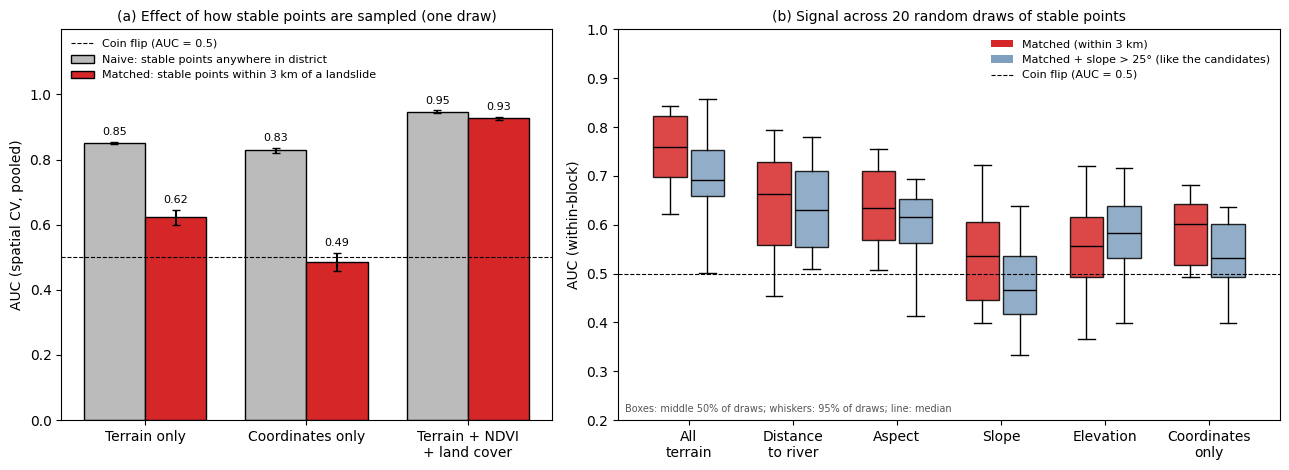

In [17]:
# Cell 17 - Figure 4 (v2): (a) sampling design, one draw; (b) feature signal across 20 draws
from matplotlib.patches import Patch

models = ["terrain", "coordinates only", "full (circular)"]
model_labels = ["Terrain only", "Coordinates only", "Terrain + NDVI\n+ land cover"]
naive = results[results["cv"] == "spatial"].groupby("model")["auc"].agg(["mean", "std"]).loc[models]
matched = results_m[results_m["cv"] == "spatial"].groupby("model")["pooled_auc"].agg(["mean", "std"]).loc[models]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.35]})

# (a) unchanged from Cell 9, but honestly labelled as one draw
x = np.arange(len(models))
w = 0.38
ax1.bar(x - w/2, naive["mean"], w, yerr=naive["std"], capsize=3, color="#bbbbbb",
        edgecolor="black", label="Naive: stable points anywhere in district")
ax1.bar(x + w/2, matched["mean"], w, yerr=matched["std"], capsize=3, color="#d62728",
        edgecolor="black", label="Matched: stable points within 3 km of a landslide")
for xi, m, s in zip(x - w/2, naive["mean"], naive["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
for xi, m, s in zip(x + w/2, matched["mean"], matched["std"]):
    ax1.text(xi, m + s + 0.02, f"{m:.2f}", ha="center", fontsize=8)
ax1.axhline(0.5, ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")
ax1.set_xticks(x)
ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.2)
ax1.set_yticks(np.arange(0, 1.01, 0.2))
ax1.set_ylabel("AUC (spatial CV, pooled)")
ax1.set_title("(a) Effect of how stable points are sampled (one draw)", fontsize=10)
ax1.legend(loc="upper left", fontsize=8, frameon=False)

# (b) box plots across 20 draws of stable points, both designs side by side
tests_b = ["terrain (all)", "only dist_river", "only aspect", "only slope", "only elevation", "coordinates only"]
labels_b = ["All\nterrain", "Distance\nto river", "Aspect", "Slope", "Elevation", "Coordinates\nonly"]
designs = [("original matched", "#d62728"), ("slope-matched", "#7f9fbf")]
for k, (design, colour) in enumerate(designs):
    data = [draws_all[(draws_all["test"] == t) & (draws_all["design"] == design)]["auc"].values
            for t in tests_b]
    pos = np.arange(len(tests_b)) + (k - 0.5) * 0.36
    bp = ax2.boxplot(data, positions=pos, widths=0.32, whis=(2.5, 97.5), showfliers=False,
                     patch_artist=True, medianprops={"color": "black"})
    for box in bp["boxes"]:
        box.set_facecolor(colour)
        box.set_alpha(0.85)
ax2.axhline(0.5, ls="--", c="black", lw=0.8)
ax2.set_xticks(np.arange(len(tests_b)))
ax2.set_xticklabels(labels_b)
ax2.set_ylim(0.2, 1.0)
ax2.set_ylabel("AUC (within-block)")
ax2.set_title("(b) Signal across 20 random draws of stable points", fontsize=10)
ax2.legend(handles=[Patch(facecolor="#d62728", label="Matched (within 3 km)"),
                    Patch(facecolor="#7f9fbf", label="Matched + slope > 25° (like the candidates)"),
                    plt.Line2D([], [], ls="--", c="black", lw=0.8, label="Coin flip (AUC = 0.5)")],
           loc="upper right", fontsize=8, frameon=False)
ax2.text(0.01, 0.02, "Boxes: middle 50% of draws; whiskers: 95% of draws; line: median",
         transform=ax2.transAxes, fontsize=7, color="#555555")

plt.tight_layout()
plt.savefig(f"{base}/figures/fig4_model_evaluation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{base}/figures/fig4_model_evaluation.pdf", bbox_inches="tight")
plt.show()

  5 of 20 models done
  10 of 20 models done
  15 of 20 models done
  20 of 20 models done

correlation single-draw vs averaged map: 0.90
pixels in the same class: 60%
pixels within one class: 95%
average disagreement between models (sd of score): 0.088
count    1767254.000
mean           0.364
std            0.186
min            0.046
25%            0.217
50%            0.329
75%            0.490
max            0.961
dtype: float64


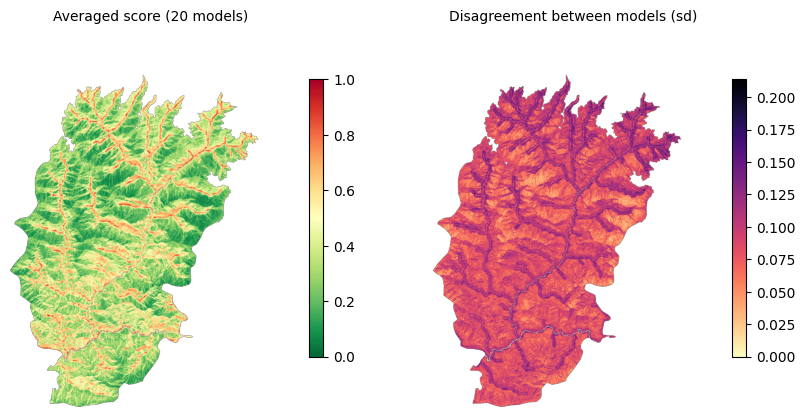

In [17]:
# Cell 18 - average 20 models (one per draw of stable points) into one map + a disagreement map
import os
from sklearn.ensemble import RandomForestClassifier

main_tif = f"{base}/rudraprayag_susceptibility.tif"
backup_tif = f"{base}/rudraprayag_susceptibility_single_draw.tif"
if not os.path.exists(backup_tif):
    os.rename(main_tif, backup_tif)          # keeping the old single-draw map as a backup
    print("old single-draw map saved as rudraprayag_susceptibility_single_draw.tif")

px_o, py_o = pools["original matched"]
score_sum = np.zeros(len(X))
score_sq = np.zeros(len(X))
for draw in range(20):
    d = draw_stable(px_o, py_o, seed=100 + draw)      # same 20 draws as Figure 4b
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=draw, n_jobs=-1)
    rf.fit(d[terrain_features], d["label"])
    s = rf.predict_proba(X)[:, 1]
    score_sum += s
    score_sq += s ** 2
    if (draw + 1) % 5 == 0:
        print(f"  {draw + 1} of 20 models done")

mean_score = score_sum / 20
sd_score = np.sqrt(np.maximum(score_sq / 20 - mean_score ** 2, 0))   # how much the 20 models disagree

def write_map(values, path):
    arr = np.full(domain.shape, np.nan, dtype="float32")
    arr[domain] = values
    prof = profile.copy()
    prof.update(count=1, dtype="float32", nodata=np.nan)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr, 1)

write_map(mean_score, main_tif)                                       # same name → notebooks 04/05 use it
write_map(sd_score, f"{base}/rudraprayag_susceptibility_sd.tif")

# how much did the single-draw map change?
with rasterio.open(backup_tif) as src:
    single = src.read(1)[domain]
def to_classes(v):
    return np.digitize(v, np.quantile(v, [0.2, 0.4, 0.6, 0.8]))
c_old, c_new = to_classes(single), to_classes(mean_score)
print(f"\ncorrelation single-draw vs averaged map: {np.corrcoef(single, mean_score)[0, 1]:.2f}")
print(f"pixels in the same class: {100 * (c_old == c_new).mean():.0f}%")
print(f"pixels within one class: {100 * (np.abs(c_old - c_new) <= 1).mean():.0f}%")
print(f"average disagreement between models (sd of score): {sd_score.mean():.3f}")
print(pd.Series(mean_score).describe().round(3))

# quick look: averaged map and where the models disagree
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 6))
for ax, vals, cmap, title, vmax in [(a, mean_score, "RdYlGn_r", "Averaged score (20 models)", 1),
                                    (b, sd_score, "magma_r", "Disagreement between models (sd)", None)]:
    arr = np.full(domain.shape, np.nan, dtype="float32")
    arr[domain] = vals
    im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.6)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.show()

In [24]:
# Cell 19 - held-out check with averaging: each held-out area scored by 20 models that never saw it
from sklearn.cluster import KMeans

rng = np.random.default_rng(7)
sample_idx = rng.choice(len(X), size=100_000, replace=False)    # enough pixels to get accurate class breaks
Xs = X.iloc[sample_idx]

# blocks from the landslides only (before, stable points made the blocks very uneven)
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(ls_xy)
draws_d = []
for k in range(20):
    d = draw_stable(px_o, py_o, seed=100 + k)                   # same 20 draws as before
    d["block"] = km.predict(d[["x", "y"]].values)
    draws_d.append(d)
ls_all = draws_d[0][draws_d[0]["label"] == 1]                   # the 38 landslides (same in every draw)
print("landslides per block:", ls_all["block"].value_counts().sort_index().to_dict())

class_names = ["Very low", "Low", "Moderate", "High", "Very high"]
ls_cls, st_cls = [], []
for g in range(5):
    ls_g = ls_all[ls_all["block"] == g]
    st_g = pd.concat([d[(d["label"] == 0) & (d["block"] == g)] for d in draws_d])   # held-out stable points, all draws
    sample_sum = np.zeros(len(Xs))
    ls_sum = np.zeros(len(ls_g))
    st_sum = np.zeros(len(st_g))
    for k, d in enumerate(draws_d):
        train = d[d["block"] != g]
        rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, random_state=k, n_jobs=-1)
        rf.fit(train[terrain_features], train["label"])
        sample_sum += rf.predict_proba(Xs)[:, 1]
        ls_sum += rf.predict_proba(ls_g[terrain_features])[:, 1]
        st_sum += rf.predict_proba(st_g[terrain_features])[:, 1]
    breaks = np.quantile(sample_sum / 20, [0.2, 0.4, 0.6, 0.8])  # this fold's own quintile classes
    ls_cls += list(np.digitize(ls_sum / 20, breaks))
    st_cls += list(np.digitize(st_sum / 20, breaks))
    print(f"  block {g} done: {len(ls_g)} held-out landslides, {len(st_g)} held-out stable points (all draws)")

ls_cls, st_cls = np.array(ls_cls), np.array(st_cls)
tab = pd.DataFrame({
    "landslides (%)": pd.Series(ls_cls).value_counts(normalize=True).reindex(range(5), fill_value=0) * 100,
    "stable points (%)": pd.Series(st_cls).value_counts(normalize=True).reindex(range(5), fill_value=0) * 100,
}, index=range(5)).round(0)
tab.index = class_names
print("\nclass of held-out points:")
print(tab)

def wilson(k, n, z=1.96):
    # 95% range for a percentage from a small sample
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return 100 * (centre - half), 100 * (centre + half)

k_ls = int((ls_cls >= 3).sum())
lo, hi = wilson(k_ls, len(ls_cls))
print(f"\nheld-out landslides in High/Very high: {100 * k_ls / len(ls_cls):.0f}% ({k_ls}/{len(ls_cls)}; 95% range {lo:.0f}–{hi:.0f}%)")
print(f"held-out stable points in High/Very high: {100 * (st_cls >= 3).mean():.0f}% (pooled over 20 draws)")
print("chance level: 40%")

landslides per block: {0: 6, 1: 6, 2: 14, 3: 2, 4: 10}
  block 0 done: 6 held-out landslides, 128 held-out stable points (all draws)
  block 1 done: 6 held-out landslides, 121 held-out stable points (all draws)
  block 2 done: 14 held-out landslides, 279 held-out stable points (all draws)
  block 3 done: 2 held-out landslides, 40 held-out stable points (all draws)
  block 4 done: 10 held-out landslides, 192 held-out stable points (all draws)

class of held-out points:
           landslides (%)  stable points (%)
Very low              0.0               10.0
Low                   5.0               22.0
Moderate              8.0               19.0
High                 26.0               26.0
Very high            61.0               23.0

held-out landslides in High/Very high: 87% (33/38; 95% range 73–94%)
held-out stable points in High/Very high: 49% (pooled over 20 draws)
chance level: 40%


In [16]:
# Cell 15 - (1) what is "only slope" picking up?  (2) how much do results depend on WHICH stable points were drawn?

# (1) slope distributions: percentiles and share of very steep ground, by group
def slope_profile(d, name):
    out = {}
    for lab, lname in [(1, "landslide"), (0, "stable")]:
        s = d.loc[d["label"] == lab, "slope"]
        out[f"{name}: {lname}"] = {"p10": s.quantile(0.1), "p50": s.median(), "p90": s.quantile(0.9),
                                   "share > 45°": (s > 45).mean()}
    return pd.DataFrame(out).T.round(2)
print("slope distributions (degrees):")
print(pd.concat([slope_profile(df_m, "original matched"), slope_profile(df_s, "slope-matched")]))

# (2) re-draw the stable points 20 times for both designs
valid_all = (elev_full > 0) & (elev_full < 3500) & (lc_full != 70) & (lc_full != 80)
ls_part = df_m.loc[df_m["label"] == 1, band_names + ["label", "x", "y"]]

def make_pool(mask, seed=0):
    # a big random pool of allowed pixels, already > 500 m from every landslide
    r = np.random.default_rng(seed)
    vr, vc = np.where(mask)
    take = r.choice(len(vr), size=min(200_000, len(vr)), replace=False)
    x = tr.c + (vc[take] + 0.5) * tr.a
    y = tr.f + (vr[take] + 0.5) * tr.e
    d_any = np.full(len(x), np.inf)
    for lx, ly in ls_xy:
        d_any = np.minimum(d_any, np.hypot(x - lx, y - ly))
    return x[d_any > 500], y[d_any > 500]

def draw_stable(pool_x, pool_y, seed):
    # one stable partner per landslide within 3 km (fallback 5/10 km), no point used twice
    r = np.random.default_rng(seed)
    used = np.zeros(len(pool_x), dtype=bool)
    chosen = []
    for lx, ly in ls_xy:
        d = np.hypot(pool_x - lx, pool_y - ly)
        for radius in [3000, 5000, 10000]:
            cand = np.where(~used & (d <= radius))[0]
            if len(cand) > 0:
                break
        j = r.choice(cand)
        used[j] = True
        chosen.append(j)
    with rasterio.open(tif) as src:
        vals = np.array(list(src.sample(list(zip(pool_x[chosen], pool_y[chosen])))))
    st = pd.DataFrame(vals, columns=band_names)
    st["label"] = 0
    st["x"], st["y"] = pool_x[chosen], pool_y[chosen]
    d = pd.concat([ls_part, st], ignore_index=True)
    d["aspect_sin"] = np.sin(np.deg2rad(d["aspect"]))
    d["aspect_cos"] = np.cos(np.deg2rad(d["aspect"]))
    return d

pools = {"original matched": make_pool(valid_all), "slope-matched": make_pool(valid_steep)}

slope distributions (degrees):
                               p10    p50    p90  share > 45°
original matched: landslide  25.83  36.94  48.03         0.18
original matched: stable     19.81  36.73  45.54         0.13
slope-matched: landslide     25.83  36.94  48.03         0.18
slope-matched: stable        27.01  36.51  47.43         0.26
